In [33]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/one-million-clicks-later/sample_submission.csv
/kaggle/input/one-million-clicks-later/train.csv
/kaggle/input/one-million-clicks-later/test.csv


In [34]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score


In [35]:
train = pd.read_csv("/kaggle/input/one-million-clicks-later/train.csv")
test = pd.read_csv("/kaggle/input/one-million-clicks-later/test.csv")


In [39]:
print("Train 'clicked' value counts:\n", train['clicked'].value_counts())

Train 'clicked' value counts:
 clicked
0.0    521090
1.0     89218
2.0         2
Name: count, dtype: int64


In [40]:
train['watch_ratio'] = train['watch_time'] / (train['video_duration'].replace(0, 1))
test['watch_ratio'] = test['watch_time'] / (test['video_duration'].replace(0, 1))

train['interaction_score'] = train['liked'] + (train['commented'] == 1).astype(int) + train['recommended']
test['interaction_score'] = test['liked'] + (test['commented'] == 1).astype(int) + test['recommended']

for period in ['Afternoon', 'Night', 'Morning', 'Evening']:
    train['is_' + period.lower()] = (train['watch_time_of_day'] == period).astype(int)
    test['is_' + period.lower()] = (test['watch_time_of_day'] == period).astype(int)

for col in ['watch_ratio', 'interaction_score'] + ['is_afternoon', 'is_night', 'is_morning', 'is_evening']:
    train[col] = train[col].fillna(0)
    test[col] = test[col].fillna(0)

In [41]:
from sklearn.preprocessing import LabelEncoder
label_cols = ['category', 'device', 'watch_time_of_day']
numeric_cols = ['video_id', 'video_duration', 'watch_time', 'liked', 'recommended', 'watch_percent',
                'watch_ratio', 'interaction_score', 'is_afternoon', 'is_night', 'is_morning', 'is_evening']

for col in label_cols:
    train[col] = train[col].fillna('missing').astype(str)
    test[col] = test[col].fillna('missing').astype(str)
    le = LabelEncoder()
    le.fit(list(train[col]) + list(test[col]))
    train[col] = le.transform(train[col])
    test[col] = le.transform(test[col])

for col in numeric_cols:
    train[col] = pd.to_numeric(train[col], errors='coerce').fillna(0)
    test[col] = pd.to_numeric(test[col], errors='coerce').fillna(0)

for df in [train, test]:
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(0, inplace=True)

In [42]:
features = label_cols + numeric_cols
X = train[features]
y = train['clicked']
test_X = test[features]

In [43]:

from sklearn.model_selection import StratifiedShuffleSplit
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, valid_idx in sss.split(X, y):
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
rf_val_probs = rf.predict_proba(X_valid)[:, 1]


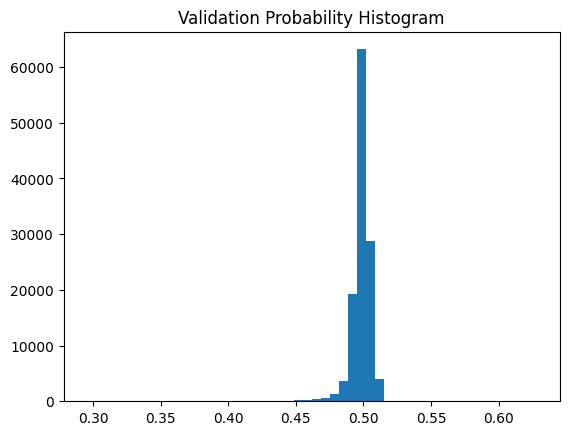

In [45]:
plt.hist(rf_val_probs, bins=50)
plt.title("Validation Probability Histogram")
plt.show()

In [46]:
thresh_candidates = np.arange(0.1, 0.6, 0.05)
for thresh in thresh_candidates:
    preds = (rf_val_probs > thresh).astype(int)
    f1 = f1_score(y_valid, preds)
    print(f"Threshold {thresh:.2f}: Validation F1 = {f1:.4f}, #Predicted clicked: {preds.sum()}")

Threshold 0.10: Validation F1 = 0.2551, #Predicted clicked: 122062
Threshold 0.15: Validation F1 = 0.2551, #Predicted clicked: 122062
Threshold 0.20: Validation F1 = 0.2551, #Predicted clicked: 122062
Threshold 0.25: Validation F1 = 0.2551, #Predicted clicked: 122062
Threshold 0.30: Validation F1 = 0.2551, #Predicted clicked: 122061
Threshold 0.35: Validation F1 = 0.2551, #Predicted clicked: 122050
Threshold 0.40: Validation F1 = 0.2551, #Predicted clicked: 122003
Threshold 0.45: Validation F1 = 0.2549, #Predicted clicked: 121635
Threshold 0.50: Validation F1 = 0.2117, #Predicted clicked: 48692
Threshold 0.55: Validation F1 = 0.0001, #Predicted clicked: 17


In [48]:

rf_test_probs = rf.predict_proba(test_X)[:, 1]
rf_test_pred = (rf_test_probs > best_thresh).astype(int)
print("Test predicted clicks:", pd.Series(rf_test_pred).value_counts())
submission_rf = pd.DataFrame({'id': test['id'], 'clicked': rf_test_pred})
submission_rf.to_csv('submission_rf.csv', index=False)
print(submission_rf.head())
print(submission_rf['clicked'].value_counts())

Test predicted clicks: 1    152578
Name: count, dtype: int64
       id  clicked
0   53363        1
1  293669        1
2   52195        1
3  260007        1
4  602213        1
clicked
1    152578
Name: count, dtype: int64
